In [6]:
import networkx as nx
import requests
from requests.exceptions import RequestException
import json
import time
import random
from tqdm import tqdm
import pandas as pd
import torch
from sklearn.preprocessing import OneHotEncoder
import numpy as np
from torch import nn
from torch_geometric.nn import GCNConv
import torch.nn.functional as F
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import confusion_matrix, classification_report

/Users/marconatale/Documents/GitHub/Magistrale/MNLP/HW1/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/marconatale/Documents/GitHub/Magistrale/MNLP/HW1/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load IDs

In [169]:
# Extract URLs from both training and validation datasets
train_df = pd.read_csv('data/train.csv')
valid_df = pd.read_csv('data/valid.csv')

# Combine URLs from both datasets
train_urls = train_df['item'].tolist()
valid_urls = valid_df['item'].tolist()
item_urls = train_urls + valid_urls

# Extract QIDs directly from the URLs
qids = [url.split('/')[-1] for url in item_urls]

# Remove any duplicate QIDs
qids = list(set(qids))

# Display information about the extracted QIDs
print(f"Total QIDs extracted: {len(qids)}")
print(f"First 5 QIDs: {qids[:5]}")
print(f"QIDs from train: {len(train_urls)}")
print(f"QIDs from valid: {len(valid_urls)}")
print(f"Total unique QIDs: {len(qids)}")

Total QIDs extracted: 6551
First 5 QIDs: ['Q1369644', 'Q63556', 'Q3450786', 'Q710558', 'Q16465938']
QIDs from train: 6251
QIDs from valid: 300
Total unique QIDs: 6551


## Knowledge Graph Construction Functions
We decided to use the sparql interface because it performs much better than the client.
The function includes a backoff delay in case of 429 error.

In [8]:
def get_entity_data(qid, prop_cache={}):
    endpoint_url = "https://query.wikidata.org/sparql"
    headers = {
        "Accept": "application/sparql-results+json",
        "User-Agent": "MNLP Homework Project/1.0 (your.email@example.com)"
    }

    query = f"""
    SELECT ?property ?propertyLabel ?value ?valueLabel WHERE {{
      wd:{qid} ?p ?statement .
      ?statement ?ps ?value .
      ?property wikibase:claim ?p ;
                wikibase:statementProperty ?ps .
      SERVICE wikibase:label {{ bd:serviceParam wikibase:language "en". }}
    }}
    """

    # Add retry mechanism with exponential backoff
    max_retries = 5
    retry_delay = 1  # Starting delay in seconds

    for retry in range(max_retries):
        try:
            response = requests.get(endpoint_url, params={'query': query}, headers=headers)
            
            # If we get a 429 error, back off and retry
            if response.status_code == 429:
                wait_time = retry_delay * (2 ** retry) + random.uniform(0, 1)
                print(f"Rate limit exceeded for {qid}. Waiting {wait_time:.2f} seconds before retry {retry+1}/{max_retries}")
                time.sleep(wait_time)
                continue
                
            response.raise_for_status()
            results = response.json()['results']['bindings']

            # Add delay
            time.sleep(1)

            label_query = f"""
            SELECT ?label WHERE {{
              wd:{qid} rdfs:label ?label .
              FILTER (lang(?label) = "en")
            }}
            """
            
            # Add delay
            time.sleep(0.5)
            
            label_response = requests.get(endpoint_url, params={'query': label_query}, headers=headers)
            
            if label_response.status_code == 429:
                wait_time = retry_delay * (2 ** retry) + random.uniform(0, 1)
                print(f"Rate limit exceeded for {qid} label query. Waiting {wait_time:.2f} seconds.")
                time.sleep(wait_time)
                continue
                
            label_response.raise_for_status()
            labels = label_response.json()['results']['bindings']
            label = labels[0]['label']['value'] if labels else 'No English Label'

            properties = {}
            for result in results:
                prop_id = result['property']['value'].split('/')[-1]
                prop_label = result.get('propertyLabel', {}).get('value', prop_id)
                value = result.get('value', {}).get('value', '')
                value_id = value.split('/')[-1] if 'entity' in value else value

                if prop_id not in properties:
                    properties[prop_id] = {
                        'label': prop_label,
                        'values': []
                    }
                if value_id not in properties[prop_id]['values']:
                    properties[prop_id]['values'].append(value_id)

            return {
                'id': qid,
                'label': label,
                'properties': properties
            }
            
        except RequestException as e:
            wait_time = retry_delay * (2 ** retry) + random.uniform(0, 1)
            print(f"Error fetching data for {qid}: {e}. Retrying in {wait_time:.2f} seconds. Attempt {retry+1}/{max_retries}")
            time.sleep(wait_time)
        except Exception as e:
            print(f"Unexpected error for {qid}: {e}")
            return None
            
    print(f"Failed to fetch data for {qid} after {max_retries} retries.")
    return None

In [171]:
def build_knowledge_graph(seed_entities, max_depth=1, relations_of_interest=None, max_nodes=100000, max_neighbors_per_node=50):

    G = nx.DiGraph()
    entity_data = {}
    entity_queue = [(entity, 0) for entity in seed_entities]  # (entity_id, current_depth)
    processed_entities = set()
    property_cache = {}  # Cache for property labels
    
    # Create a request cache to avoid requesting the same entity multiple times
    entity_cache = {}
    
    # Use standard tqdm for progress tracking
    total_entities = len(entity_queue)
    with tqdm(total=total_entities, desc="Building Knowledge Graph") as pbar:
        while entity_queue and len(processed_entities) < max_nodes:
            current_qid, current_depth = entity_queue.pop(0)
            
            if current_qid in processed_entities:
                pbar.update(1)
                continue
                
            processed_entities.add(current_qid)
            
            # Check if we already have this entity's data in cache
            if current_qid in entity_cache:
                data = entity_cache[current_qid]
            else:
                # Get entity data from Wikidata with property cache
                data = get_entity_data(current_qid, property_cache)
                # Store in cache for future use
                if data:
                    entity_cache[current_qid] = data
            
            if not data:
                pbar.update(1)
                continue
                
            # Store entity data
            entity_data[current_qid] = data
            
            # Add node to graph with attributes
            G.add_node(current_qid, label=data['label'], type='entity')
            
            # If we've reached the maximum depth, don't add any more neighbors
            if current_depth >= max_depth:
                pbar.update(1)
                continue
            
            # Process properties and add edges to graph
            neighbors_added = 0
            
            # Get all potential neighbors first, then filter to avoid bias towards early properties
            all_neighbors = []
            for prop_id, prop_data in data['properties'].items():
                # Skip if not in relations of interest
                if relations_of_interest and prop_id not in relations_of_interest:
                    continue
                    
                for value_id in prop_data['values']:
                    all_neighbors.append((prop_id, prop_data['label'], value_id))
            
            # Limit number of neighbors per node
            for prop_id, prop_label, value_id in all_neighbors[:max_neighbors_per_node]:
                # Add edge to graph
                G.add_edge(
                    current_qid, 
                    value_id, 
                    relation=prop_id,
                    relation_label=prop_label
                )
                
                # Add value entity to queue for processing if not already processed
                if value_id not in processed_entities and len(processed_entities) < max_nodes:
                    entity_queue.append((value_id, current_depth + 1))
                    total_entities += 1
                    pbar.total = total_entities
                
                neighbors_added += 1
                if neighbors_added >= max_neighbors_per_node:
                    break
            
            # Reduced sleep time and only applied when needed
            if neighbors_added > 0:
                time.sleep(0.2)  # Shorter delay between entities with neighbors
            
            pbar.update(1)
            pbar.set_postfix({"Nodes": G.number_of_nodes(), "Edges": G.number_of_edges(), "Queue": len(entity_queue)})
    
    return G, entity_data

## Define Relations of Interest

We'll focus on specific relations that are relevant to our task of identifying cultural agnosticism.

In [172]:
relations = [
    'P31',   # instance of
    'P279',  # subclass of
    'P17',   # country
    'P361',  # part of
    'P527',  # has part
    'P921',  # main subject
    'P2670', # has parts of the class
    'P1269', # aspect of
    'P106',  # occupation
    'P5008', # on focus list of Wikimedia project
    'P1365', # replaces
    'P155',  # follows
    'P156'   # followed by
]

## Build the Knowledge Graph

In [173]:
# Build the knowledge graph with a depth of 1 and explicit limits
G, entity_data = build_knowledge_graph(
    qids, 
    max_depth=1, 
    relations_of_interest=relations,
    max_neighbors_per_node=10
)

print(f"Knowledge graph built with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

Building Knowledge Graph: 100%|██████████| 29335/29335 [8:41:13<00:00,  1.07s/it, Nodes=12722, Edges=23941, Queue=22784]   

Knowledge graph built with 12722 nodes and 23941 edges.


## Save Graph
Let's save our graph data for use in the next steps of the project.

In [174]:
# Create graph directory if it doesn't exist
os.makedirs('graph', exist_ok=True)

# Convert the graph to a JSON-serializable format
graph_data = nx.node_link_data(G)

# Save the graph
with open('graph/knowledge_graph.json', 'w') as f:
    json.dump(graph_data, f)

# Save entity data
with open('graph/entity_data.json', 'w') as f:
    json.dump(entity_data, f)

print("Graph and entity data saved to files in the 'graph' directory.")

Graph and entity data saved to files in the 'graph' directory.


## Load Graph
Let's load the previously created graph, to prepare the data for the GNN training process

In [4]:
# --- Load graph ---
with open("graph/knowledge_graph.json") as f:
    kg = json.load(f)

G = nx.DiGraph()
for node in kg["nodes"]:
    G.add_node(node["id"], label=node.get("label", ""), type=node.get("type", ""))
for edge in kg["links"]:
    G.add_edge(edge["source"], edge["target"], relation=edge.get("relation_label", ""))

In [5]:
# Analyze the graph structure
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

edge_relations = {}
for _, _, data in G.edges(data=True):
    relation = data.get('relation', 'unknown')
    edge_relations[relation] = edge_relations.get(relation, 0) + 1

# Display the results
print(f"Graph Analysis:")
print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")


print("\nTop 10 edge relations:")
for relation, count in sorted(edge_relations.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"- {relation}: {count} edges ({count/num_edges:.2%})")

Graph Analysis:
Number of nodes: 12722
Number of edges: 23941

Top 10 edge relations:
- instance of: 7671 edges (32.04%)
- subclass of: 5027 edges (21.00%)
- occupation: 4948 edges (20.67%)
- country: 2204 edges (9.21%)
- has part(s): 1579 edges (6.60%)
- on focus list of Wikimedia project: 872 edges (3.64%)
- part of: 624 edges (2.61%)
- facet of: 339 edges (1.42%)
- main subject: 265 edges (1.11%)
- replaces: 113 edges (0.47%)


In [6]:
# Find nodes with the most incoming edges
in_degrees = dict(G.in_degree())
top_incoming = sorted(in_degrees.items(), key=lambda x: x[1], reverse=True)[:20]

print("Top 20 nodes with the most incoming edges:")
for node, degree in top_incoming:
    node_label = G.nodes[node].get('label', 'No Label')
    print(f"{node} ({node_label}): {degree} incoming edges")


Top 20 nodes with the most incoming edges:
Q5 (human): 910 incoming edges
Q6173448 (Wikipedia:Vital articles/Level/4): 339 incoming edges
Q30 (United States): 301 incoming edges
Q36180 (writer): 267 incoming edges
Q33999 (actor): 195 incoming edges
Q183 (Germany): 180 incoming edges
Q28640 (profession): 167 incoming edges
Q82955 (politician): 159 incoming edges
Q1622272 (university teacher): 146 incoming edges
Q2526255 (film director): 144 incoming edges
Q10800557 (film actor): 139 incoming edges
Q28389 (screenwriter): 116 incoming edges
Q145 (United Kingdom): 115 incoming edges
Q49757 (poet): 114 incoming edges
Q12737077 (occupation): 111 incoming edges
Q39 (Switzerland): 111 incoming edges
Q41176 (building): 107 incoming edges
Q107357104 (type of dance): 107 incoming edges
Q11424 (film): 106 incoming edges
Q639669 (musician): 102 incoming edges


In [7]:
# --- Load labeled data from CSV files ---
train_df = pd.read_csv("data/train.csv")
valid_df = pd.read_csv("data/valid.csv")

# Add QID column extracted from the item URL
train_df["qid"] = train_df["item"].apply(lambda x: x.split("/")[-1])
valid_df["qid"] = valid_df["item"].apply(lambda x: x.split("/")[-1])

# Filter to only include QIDs that are in our knowledge graph
train_df = train_df[train_df["qid"].isin(G.nodes)]
valid_df = valid_df[valid_df["qid"].isin(G.nodes)]

# Map string labels to integer IDs for the model
label_map = {"cultural agnostic": 0, "cultural exclusive": 1, "cultural representative": 2}
train_df["label_id"] = train_df["label"].map(label_map)
valid_df["label_id"] = valid_df["label"].map(label_map)

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(valid_df)}")

Training samples: 6251
Validation samples: 300


In [ ]:
# --- Features ---
combined_df = pd.concat([train_df, valid_df])

# Process textual features
# 1. Combine textual data
combined_df['text_features'] = combined_df['name'] + ' ' + combined_df['description'] + ' ' + combined_df['subcategory']
print("Sample text feature:", combined_df['text_features'].iloc[0])

# 2. Convert text to TF-IDF features
tfidf_vectorizer = TfidfVectorizer(max_features=100, stop_words='english')
text_features = tfidf_vectorizer.fit_transform(combined_df['text_features'])
print(f"TF-IDF features shape: {text_features.shape}")

# 3. Reduce dimensionality with Truncated SVD (similar to PCA but works on sparse matrices)
svd = TruncatedSVD(n_components=20)
text_features_reduced = svd.fit_transform(text_features)
print(f"Reduced text features shape: {text_features_reduced.shape}")
print(f"Explained variance ratio: {svd.explained_variance_ratio_.sum():.2f}")

# Create features using one-hot encoding for categorical features
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
categorical_features = encoder.fit_transform(combined_df[["type", "category"]])

# Combine categorical and text features
X = np.hstack([categorical_features, text_features_reduced])
print(f"Combined features shape: {X.shape}")

# Create mapping from QID to index for all nodes
all_qids = combined_df["qid"].values
qid_to_idx = {qid: i for i, qid in enumerate(all_qids)}

# Get labels for all data
y = combined_df["label_id"].values

# Create edge index and edge attributes for Graph Neural Network
edge_index, edge_types = [], []
rel_map = {}
rel_id = 0

for src, tgt, d in G.edges(data=True):
    if src in qid_to_idx and tgt in qid_to_idx:
        edge_index.append([qid_to_idx[src], qid_to_idx[tgt]])
        rel = d.get("relation", "unknown")
        if rel not in rel_map:
            rel_map[rel] = rel_id
            rel_id += 1
        edge_types.append(rel_map[rel])

edge_index = torch.tensor(edge_index).t().contiguous()
edge_attr = torch.tensor(edge_types)

# Convert features and labels to tensors
x = torch.tensor(X, dtype=torch.float)
y_tensor = torch.tensor(y, dtype=torch.long)

# Separate training and validation again
n_samples = len(combined_df)
n_train = len(train_df)

train_mask = torch.zeros(n_samples, dtype=torch.bool)
val_mask = torch.zeros(n_samples, dtype=torch.bool)

train_mask[:n_train] = True
val_mask[n_train:] = True

print(f"Features shape: {x.shape}")
print(f"Number of edges: {edge_index.shape[1]}")
print(f"Number of relation types: {len(rel_map)}")

Sample text feature: 916 2012 film by M. Mohanan film
TF-IDF features shape: (6551, 100)
Reduced text features shape: (6551, 20)
Explained variance ratio: 0.37
Combined features shape: (6551, 41)
Features shape: torch.Size([6551, 41])
Number of edges: 2813
Number of relation types: 12


/Users/marconatale/Documents/GitHub/Magistrale/MNLP/HW1/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/Users/marconatale/Documents/GitHub/Magistrale/MNLP/HW1/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/Users/marconatale/Documents/GitHub/Magistrale/MNLP/HW1/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat


## GCN Model Definition

We'll create a Graph Convolutional Network (GCN) model enhanced to handle our expanded feature set.

In [10]:
class GCN(torch.nn.Module):
    def __init__(self, in_features, hidden_features_1, hidden_features_2, num_classes, dropout_rate=0.3):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_features, hidden_features_1)
        self.conv2 = GCNConv(hidden_features_1, hidden_features_2)
        self.batch_norm1 = nn.BatchNorm1d(hidden_features_1)
        self.batch_norm2 = nn.BatchNorm1d(hidden_features_2)
        self.out = nn.Linear(hidden_features_2, num_classes)
        self.dropout = nn.Dropout(dropout_rate)
        
    def forward(self, x, edge_index):
        # First GCN layer
        x = self.conv1(x, edge_index)
        x = self.batch_norm1(x)
        x = F.relu(x)
        x = self.dropout(x)
        
        # Second GCN layer
        x = self.conv2(x, edge_index)
        x = self.batch_norm2(x)
        x = F.relu(x)
        x = self.dropout(x)
        
        # Output layer
        x = self.out(x)
        return x

## GCN Model Training

Now we'll set up a training loop for our GCN model using the training split of the knowledge graph data.

In [9]:
def train(model, x, edge_index, y, train_mask, val_mask, epochs=100, lr=0.01, weight_decay=5e-4):
    # Initialize the optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    # Loss function
    criterion = torch.nn.CrossEntropyLoss()
    
    # For tracking metrics
    best_val_acc = 0
    best_epoch = 0
    training_losses = []
    validation_accuracies = []
    
    # Training loop
    for epoch in range(epochs):
        # Set model to training mode
        model.train()
        
        # Forward pass
        optimizer.zero_grad()
        out = model(x, edge_index)
        
        # Compute loss on training nodes
        loss = criterion(out[train_mask], y[train_mask])
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Record training loss
        training_losses.append(loss.item())
        
        # Evaluate on validation set
        model.eval()
        with torch.no_grad():
            # Forward pass
            out = model(x, edge_index)
            
            # Get predictions
            _, pred = out.max(dim=1)
            
            # Compute validation accuracy
            correct = pred[val_mask] == y[val_mask]
            val_acc = int(correct.sum()) / int(val_mask.sum())
            validation_accuracies.append(val_acc)
            
            # Update best validation accuracy
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_epoch = epoch
        
        # Print progress every 10 epochs
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'Epoch: {epoch+1:03d}, Train Loss: {loss.item():.4f}, Val Accuracy: {val_acc:.4f}')
    
    print(f'\nTraining completed!')
    print(f'Best validation accuracy: {best_val_acc:.4f} (Epoch {best_epoch+1})')
    
    return model, training_losses, validation_accuracies

In [12]:
# Initialize model parameters
# [64,96], 0.3, 0.005
in_features = x.shape[1] 
hidden_features_1 = 64
hidden_features_2 = 96
dropout_rate = 0.3
learning_rate = 0.005
weight_decay = 5e-4
num_classes = 3

# Create the GCN model
model_gcn = GCN(in_features, hidden_features_1, hidden_features_2, num_classes, dropout_rate = dropout_rate)

# Train the GCN model
model_gcn, train_losses, val_accuracies = train(
    model=model_gcn, 
    x=x, 
    edge_index=edge_index, 
    y=y_tensor, 
    train_mask=train_mask, 
    val_mask=val_mask,
    epochs=300,
    lr=learning_rate,
    weight_decay=weight_decay
)

Epoch: 001, Train Loss: 1.2191, Val Accuracy: 0.4500
Epoch: 010, Train Loss: 0.8750, Val Accuracy: 0.5400
Epoch: 020, Train Loss: 0.8352, Val Accuracy: 0.5500
Epoch: 030, Train Loss: 0.8094, Val Accuracy: 0.5733
Epoch: 020, Train Loss: 0.8352, Val Accuracy: 0.5500
Epoch: 030, Train Loss: 0.8094, Val Accuracy: 0.5733
Epoch: 040, Train Loss: 0.7960, Val Accuracy: 0.5967
Epoch: 050, Train Loss: 0.7787, Val Accuracy: 0.5833
Epoch: 040, Train Loss: 0.7960, Val Accuracy: 0.5967
Epoch: 050, Train Loss: 0.7787, Val Accuracy: 0.5833
Epoch: 060, Train Loss: 0.7746, Val Accuracy: 0.5967
Epoch: 070, Train Loss: 0.7579, Val Accuracy: 0.6000
Epoch: 060, Train Loss: 0.7746, Val Accuracy: 0.5967
Epoch: 070, Train Loss: 0.7579, Val Accuracy: 0.6000
Epoch: 080, Train Loss: 0.7482, Val Accuracy: 0.6067
Epoch: 090, Train Loss: 0.7459, Val Accuracy: 0.6067
Epoch: 080, Train Loss: 0.7482, Val Accuracy: 0.6067
Epoch: 090, Train Loss: 0.7459, Val Accuracy: 0.6067
Epoch: 100, Train Loss: 0.7320, Val Accuracy: 

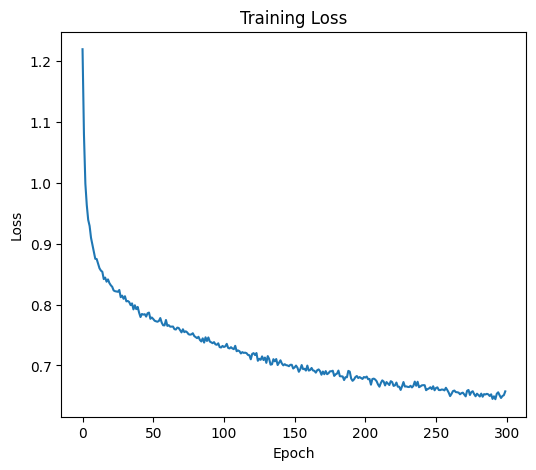

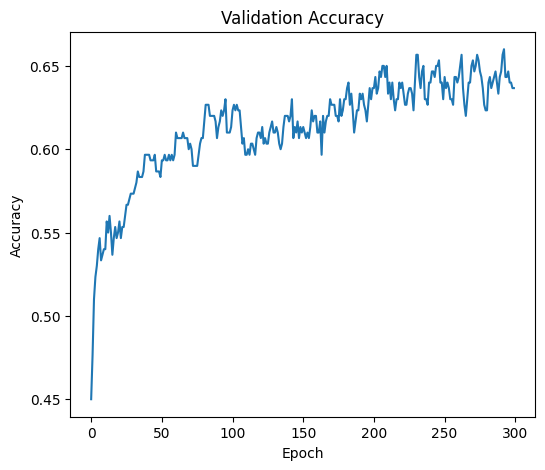

In [13]:
import matplotlib.pyplot as plt

# Plot training loss
plt.figure(figsize=(6, 5))
plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# Plot validation accuracy
plt.figure(figsize=(6, 5))
plt.plot(val_accuracies)
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

## Model Evaluation

Let's evaluate our model's performance using a confusion matrix to understand how well it's predicting each class.

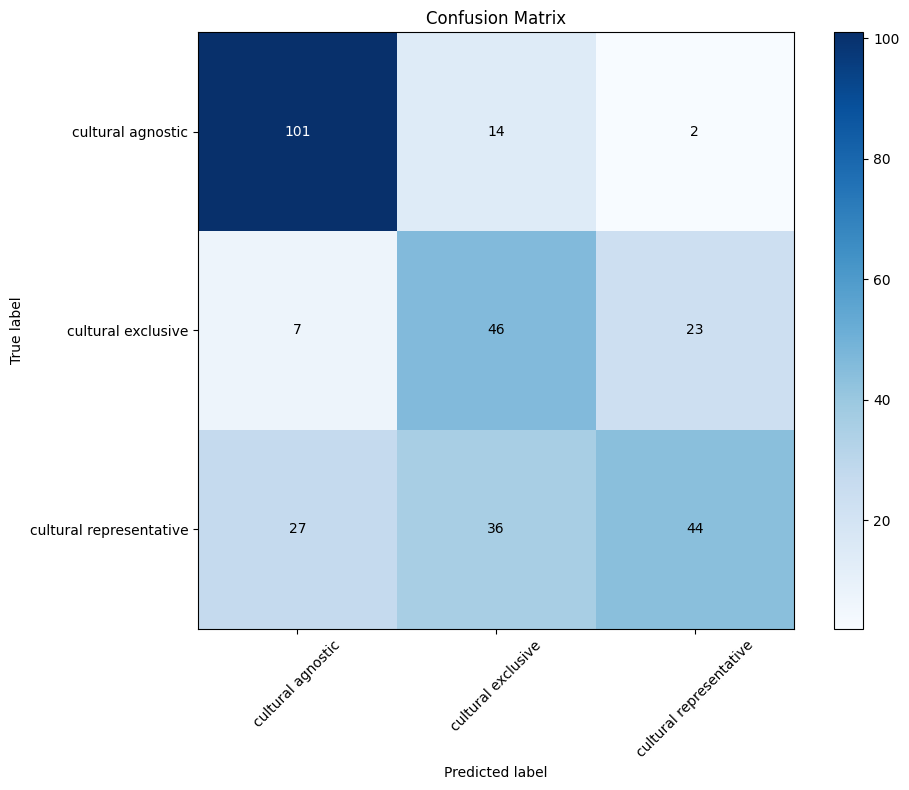

                         precision    recall  f1-score   support

      cultural agnostic       0.75      0.86      0.80       117
     cultural exclusive       0.48      0.61      0.53        76
cultural representative       0.64      0.41      0.50       107

               accuracy                           0.64       300
              macro avg       0.62      0.63      0.61       300
           weighted avg       0.64      0.64      0.63       300



In [14]:
# Evaluate the model
model_gcn.eval()
with torch.no_grad():
    out = model_gcn(x, edge_index)
    _, pred = out.max(dim=1)

# Get predictions and true labels for validation set
y_true = y_tensor[val_mask].cpu().numpy()
y_pred = pred[val_mask].cpu().numpy()

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display confusion matrix using matplotlib
plt.figure(figsize=(10, 8))
class_names = ['cultural agnostic', 'cultural exclusive', 'cultural representative']

# Create the plot
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

# Add tick marks and labels
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

# Add text annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

# Print classification report
print(classification_report(y_true, y_pred, target_names=class_names))

## Save Trained Model

Let's save our trained GCN model for future use.

In [ ]:
# Create a directory for saving the model if it doesn't exist
os.makedirs('non_lm_model', exist_ok=True)

# Save the model parameters
model_path = 'non_lm_model/non_lm_model.pth'
torch.save(model_gcn.state_dict(), model_path)

# Save model metadata and preprocessing components for later use
model_metadata = {
    'in_features': in_features,
    'hidden_features_1': hidden_features_1,
    'hidden_features_2': hidden_features_2,
    'num_classes': num_classes,
    'dropout_rate': dropout_rate,
    'qid_to_idx': qid_to_idx,
    'class_names': class_names,
}

# Save the preprocessors
with open('non_lm_model/tfidf_vectorizer.pkl', 'wb') as f:
    import pickle
    pickle.dump(tfidf_vectorizer, f)
    
with open('non_lm_model/svd.pkl', 'wb') as f:
    pickle.dump(svd, f)
    
with open('non_lm_model/encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)
    
with open('non_lm_model/model_metadata.json', 'w') as f:
    # Convert qid_to_idx keys to strings for JSON serialization
    serializable_qid_to_idx = {str(k): v for k, v in qid_to_idx.items()}
    json_metadata = model_metadata.copy()
    json_metadata['qid_to_idx'] = serializable_qid_to_idx
    json.dump(json_metadata, f)

print(f"Model saved to {model_path}")
print(f"Preprocessing components and metadata saved in the 'non_lm_model' directory")

Model saved to model/non_lm_model.pth
Preprocessing components and metadata saved in the 'model' directory


## Load Model and Make Predictions

Now we'll implement code to load the trained model and make predictions on new test data.

This will be the part of code included for testing in the delivered colab notebook

In [1]:
import pickle

In [2]:
def load_model_and_preprocessors():
    # Load metadata
    with open('non_lm_model/model_metadata.json', 'r') as f:
        metadata = json.load(f)
    
    # Convert qid_to_idx keys back from strings to original format
    metadata['qid_to_idx'] = {k: v for k, v in metadata['qid_to_idx'].items()}
    
    # Load preprocessors
    with open('non_lm_model/tfidf_vectorizer.pkl', 'rb') as f:
        tfidf_vectorizer = pickle.load(f)
        
    with open('non_lm_model/svd.pkl', 'rb') as f:
        svd = pickle.load(f)
        
    with open('non_lm_model/encoder.pkl', 'rb') as f:
        encoder = pickle.load(f)
    
    # Recreate the model with the same architecture
    model = GCN(
        metadata['in_features'], 
        metadata['hidden_features_1'], 
        metadata['hidden_features_2'], 
        metadata['num_classes'], 
        metadata['dropout_rate']
    )
    
    # Load the saved model parameters
    model.load_state_dict(torch.load('non_lm_model/non_lm_model.pth'))
    model.eval()  # Set the model to evaluation mode
    
    return model, tfidf_vectorizer, svd, encoder, metadata

Uses a three-tier approach to ensure connectivity:
First tries direct connections (e.g., pasta → Italy)
If no connections found, tries reverse connections by checking if any existing entity refers to the new entity
As a last resort, tries any available relationship that connects to an existing node

In [16]:
def process_test_data_for_prediction(test_file, graph_file='graph/knowledge_graph.json', entity_file='graph/entity_data.json'):
    # Load test data
    test_df = pd.read_csv(test_file)
    
    # Extract QIDs from the item URLs
    test_df['qid'] = test_df['item'].apply(lambda x: x.split('/')[-1])
    
    # Load the knowledge graph
    with open(graph_file) as f:
        kg = json.load(f)
        
    G = nx.DiGraph()
    for node in kg['nodes']:
        G.add_node(node['id'], label=node.get('label', ''), type=node.get('type', ''))
    for edge in kg['links']:
        G.add_edge(edge['source'], edge['target'], relation=edge.get('relation_label', ''))
        
    # Load entity data which contains Wikidata properties
    with open(entity_file) as f:
        entity_data = json.load(f)
    
    # Count how many new entities we're adding
    new_entities = [qid for qid in test_df['qid'].unique() if qid not in G.nodes]
    print(f"Adding {len(new_entities)} new entities from test data to the knowledge graph")
    
    # Add new nodes to the graph
    for qid in new_entities:
        entity_info = test_df[test_df['qid'] == qid].iloc[0]
        # Add node with label from the test data
        G.add_node(qid, label=entity_info['name'], type=entity_info.get('type', ''))
    
    # Important relationships to check for connections
    important_relations = [
        'P31',   # instance of
        'P279',  # subclass of
        'P17',   # country
        'P361',  # part of
        'P527',  # has part
        'P921',  # main subject
        'P2670', # has parts of the class
        'P1269', # aspect of
        'P106',  # occupation
        'P5008', # on focus list of Wikimedia project
        'P1365', # replaces
        'P155',  # follows
        'P156'   # followed by
    ]
    
    print("Connecting new entities to the graph based on direct Wikidata relationships...")
    
    # Query Wikidata for new entities and connect them based on actual relationships
    for new_qid in new_entities:
        # Get entity data from Wikidata
        print(f"Fetching Wikidata information for {new_qid}...")
        entity_info = get_entity_data(new_qid)
        
        if not entity_info or 'properties' not in entity_info:
            print(f"No Wikidata properties found for {new_qid}, skipping connections")
            continue
            
        connections_made = 0
        
        # For each property of the new entity
        for prop_id, prop_data in entity_info['properties'].items():
            if prop_id in important_relations:
                # Look through the values of this property (e.g., countries, locations)
                for value_id in prop_data['values']:
                    # If the value exists in our graph, create a connection
                    if value_id in G.nodes:
                        G.add_edge(new_qid, value_id, relation=prop_data['label'])
                        print(f"Connected {new_qid} to {value_id} via {prop_data['label']}")
                        connections_made += 1
        
        # If we couldn't establish any forward connections, try reverse connections
        if connections_made == 0:
            # Check if any existing entity refers to this new entity
            for existing_entity_id, existing_data in entity_data.items():
                if existing_entity_id not in G.nodes:
                    continue
                    
                if 'properties' not in existing_data:
                    continue
                    
                for prop_id, prop_data in existing_data['properties'].items():
                    if prop_id in important_relations:
                        for value_id in prop_data['values']:
                            if value_id == new_qid:
                                G.add_edge(existing_entity_id, new_qid, relation=prop_data['label'])
                                print(f"Connected {existing_entity_id} to {new_qid} via {prop_data['label']} (reverse connection)")
                                connections_made += 1
        
        # If still no connections, try one more approach with the entity's Wikidata properties
        if connections_made == 0 and entity_info and 'properties' in entity_info:
            # Look for any matching entities in our graph that this entity refers to
            for prop_id, prop_data in entity_info['properties'].items():
                for value_id in prop_data['values']:
                    if value_id in G.nodes:
                        G.add_edge(new_qid, value_id, relation=prop_data['label'])
                        print(f"Connected {new_qid} to {value_id} via {prop_data['label']} (fallback connection)")
                        connections_made += 1
                        break
                if connections_made > 0:
                    break
        
        # If we still couldn't establish any connections, report it
        if connections_made == 0:
            print(f"Warning: {new_qid} could not be connected to the existing graph")
    
    # Load model and preprocessors
    model, tfidf_vectorizer, svd, encoder, metadata = load_model_and_preprocessors()
    
    # Generate features
    test_df['text_features'] = test_df['name'] + ' ' + test_df['description'] + ' ' + test_df['subcategory']
    text_features = tfidf_vectorizer.transform(test_df['text_features'])
    text_features_reduced = svd.transform(text_features)
    
    # Handle unknown categories in test data
    print("Checking for unknown categories in test data...")
    
    # Get the original categories from the encoder
    original_type_categories = encoder.categories_[0]
    original_category_categories = encoder.categories_[1]

    test_df['type']     = test_df['type'].str.lower()
    test_df['category'] = test_df['category'].str.lower()
    
    # Check and fix the 'type' column
    test_df['type'] = test_df['type'].replace({"named entity": "entity"})

    unknown_types = set(test_df['type'].unique()) - set(original_type_categories)
    if unknown_types:
        print(f"Found unknown categories in 'type' column: {unknown_types}")
        # Replace unknown types with the most frequent type from training
        most_common_type = original_type_categories[0]
        for unknown_type in unknown_types:
            test_df.loc[test_df['type'] == unknown_type, 'type'] = most_common_type
            print(f"Replaced '{unknown_type}' with '{most_common_type}'")
    
    # Check and fix the 'category' column
    unknown_categories = set(test_df['category'].unique()) - set(original_category_categories)
    if unknown_categories:
        print(f"Found unknown categories in 'category' column: {unknown_categories}")
        # Replace unknown categories with the most frequent category from training
        most_common_category = original_category_categories[0]
        for unknown_category in unknown_categories:
            test_df.loc[test_df['category'] == unknown_category, 'category'] = most_common_category
            print(f"Replaced '{unknown_category}' with '{most_common_category}'")
    
    # Now transform with the fixed categories
    categorical_features = encoder.transform(test_df[['type', 'category']])
    
    # Combine features
    X_test = np.hstack([categorical_features, text_features_reduced])
    
    # Convert features to tensor
    x_test = torch.tensor(X_test, dtype=torch.float)
    
    # Create edge index for test data
    qid_to_idx = {qid: i for i, qid in enumerate(test_df['qid'].values)}
    
    edge_index = []
    for src, tgt in G.edges():
        if src in qid_to_idx and tgt in qid_to_idx:
            edge_index.append([qid_to_idx[src], qid_to_idx[tgt]])
    
    # If there are edges, convert to tensor format
    if edge_index:
        edge_index = torch.tensor(edge_index).t().contiguous()
    else:
        # Create empty edge index if no edges exist
        edge_index = torch.zeros((2, 0), dtype=torch.long)
    
    print(f"Prepared test data with {len(test_df)} entities and {len(edge_index[0]) if len(edge_index) > 0 else 0} edges")
    
    return test_df, x_test, edge_index, model, metadata['class_names']

In [17]:
def predict_on_test_data(test_file='data/test.csv', output_file='non_lm_predictions.csv'):
    # Process test data
    test_df, x_test, edge_index, model, class_names = process_test_data_for_prediction(test_file)
    
    # Make predictions
    model.eval()
    with torch.no_grad():
        out = model(x_test, edge_index)
        _, pred = out.max(dim=1)
    
    # Convert numeric predictions to class labels
    predictions = [class_names[p.item()] for p in pred]
    
    # Add predictions to the dataframe
    test_df['label'] = predictions
    
    # Save results to CSV without the qid column
    output_df = test_df.drop(['text_features', 'qid'], axis=1, errors='ignore')
    output_df.to_csv(output_file, index=False)
    
    print(f"Predictions saved to {output_file}")
        
    return test_df

## Run Prediction on Test Data

Let's run the prediction pipeline on a test file.

All the new entities in the test file will be attached to the existing knowledge graph using the same approach as the building process, after attaching them the prediction is carried out on the new nodes.

In [19]:
predictions_df = predict_on_test_data(test_file='data/test_unlabeled.csv', output_file='Saffron_Mafia_output_modello1.csv')


Adding 263 new entities from test data to the knowledge graph
Connecting new entities to the graph based on direct Wikidata relationships...
Fetching Wikidata information for Q2427430...
Connected Q2427430 to Q13418847 via instance of
Fetching Wikidata information for Q15789...
Connected Q15789 to Q847017 via instance of
Connected Q15789 to Q476028 via instance of
Connected Q15789 to Q183 via country
Fetching Wikidata information for Q582496...
Connected Q582496 to Q155 via country
Connected Q582496 to Q327333 via instance of
Fetching Wikidata information for Q572811...
Connected Q572811 to Q378427 via instance of
Connected Q572811 to Q30 via country
Connected Q572811 to Q378427 via subclass of
Fetching Wikidata information for Q1866547...
Connected Q1866547 to Q200764 via instance of
Connected Q1866547 to Q210272 via instance of
Connected Q1866547 to Q45 via country
Fetching Wikidata information for Q19081...
Connected Q19081 to Q7239 via subclass of
Connected Q19081 to Q16521 via ins